In [1]:
from src.objetos import Dados, camada_densa, rede_neural, gradiente_conjugado

In [2]:
# Caminho dos dados e dos rotulos
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)


In [3]:
# Escolha do método de separação dos dados
dados._holdout(0.6, 0.2)

In [ ]:
# Parâmetros da nossa rede neural
epocas = 500
taxa_aprendizado = 2
lambda_reg = 0.01
arquitetura_camadas = [400, 25, 10]

In [ ]:
#Treinamento da rede com otimização por meio do método do Gradiente Conjugado
import numpy as np

epocas = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
custos = []

for max_it in epocas:
    camadas = []

    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
    # Aplica softmax na ultima camada
    camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[-2], 
            tamanho_saida=arquitetura_camadas[-1],
            funcao_de_ativacao='softmax'
            )
    camadas.append(camada)

    # Inicialização da rede neural
    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

    otimizador = gradiente_conjugado.GradienteConjugado(rede, max_it, lambda_reg)
    custo = otimizador.treino(dados.conjunto_treinamento[0], dados.conjunto_treinamento[1])
    custos.append(custo)

Treinamento concluído. Sucesso: False. Motivo: Maximum number of iterations has been exceeded.

[[0.84456557 0.84197617 0.83861688 ... 0.84593525 0.85553144 0.84815564]
 [0.84202333 0.83662063 0.83754712 ... 0.84467156 0.85155874 0.84551331]
 [0.85199974 0.84622592 0.84559642 ... 0.85369513 0.85935505 0.85483248]
 ...
 [0.85216653 0.85273667 0.84863567 ... 0.85767867 0.86028784 0.85767449]
 [0.84620287 0.84489691 0.83958433 ... 0.84834622 0.85806363 0.84972474]
 [0.85568982 0.8563248  0.85314199 ... 0.86008265 0.8634171  0.86568149]]

0.15902847892519512
Treinamento concluído. Sucesso: False. Motivo: Maximum number of iterations has been exceeded.

[[0.98500012 0.98771903 0.98865349 ... 0.9907815  0.98611006 0.98893358]
 [0.98539893 0.98849886 0.98932035 ... 0.99124696 0.98702151 0.98975604]
 [0.98642292 0.98926983 0.98962422 ... 0.99204711 0.98772932 0.99068297]
 ...
 [0.98519767 0.98827832 0.98871158 ... 0.99101107 0.98713813 0.98997331]
 [0.98492304 0.98784344 0.98828624 ... 0.99086

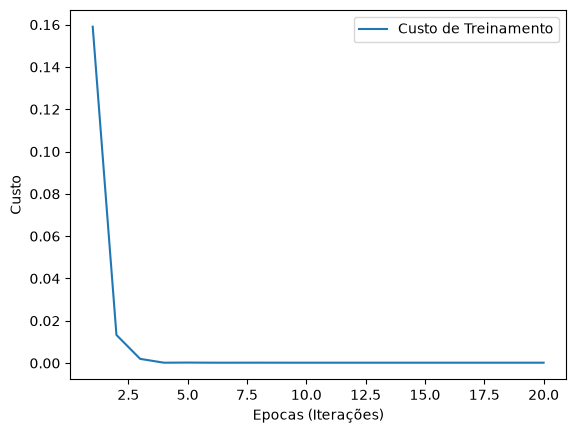

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epocas,custos, label="Custo de Treinamento")
plt.xlabel("Epocas (Iterações)")
plt.ylabel("Custo")
plt.legend()
plt.show()

In [ ]:
#Treinamento da rede com otimização por meio do método do Gradiente Conjugado
import numpy as np

acuracy_CG = []

# Parâmetros da nossa rede neural
epocas = 500
taxa_aprendizado = 2
lambda_reg = [0.25,0.5,0.75,1,1.25,1.5,1.75,2,2.25,3,5,7,10]
arquitetura_camadas = [400, 25, 10]

for lambda_i in lambda_reg:
    camadas = []
    
    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
    # Aplica softmax na ultima camada
    camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[-2], 
            tamanho_saida=arquitetura_camadas[-1],
            funcao_de_ativacao='softmax'
            )
    camadas.append(camada)
    # Inicialização da rede neural
    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_i)

    otimizador = gradiente_conjugado.GradienteConjugado(rede, epocas, lambda_i)
    custo = otimizador.treino(dados.conjunto_treinamento[0], dados.conjunto_treinamento[1])

    y_teste = rede._avalia(dados.conjunto_teste[0])
    classes_pred = np.argmax(y_teste, axis=0) + 1
    classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
    acertos = np.sum(classes_pred == classes_real)
    num_amostras = dados.conjunto_teste[0].shape[1]

    acuracia_modelo = acertos/num_amostras

    acuracy_CG.append(acuracia_modelo)
    

In [ ]:
import numpy as np

acuracy_ML = []

# Parâmetros da nossa rede neural
epocas = 500
taxa_aprendizado = 2
lambda_reg = [0.25,0.5,0.75,1,1.25,1.5,1.75,2,2.25,3,5,7,10]
arquitetura_camadas = [400, 25, 10]

for lambda_i in lambda_reg:
    camadas = []
    
    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
    # Aplica softmax na ultima camada
    camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[-2], 
            tamanho_saida=arquitetura_camadas[-1],
            funcao_de_ativacao='softmax'
            )
    camadas.append(camada)
    # Inicialização da rede neural
    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_i)

    rede.treinar(
        epocas=epocas,
        taxa_aprendizado=taxa_aprendizado,
        conjunto_treinamento=dados.conjunto_treinamento,
        conjunto_validacao=dados.conjunto_validacao,
        regularizador_lambda=lambda_i
    )

    y_teste = rede._avalia(dados.conjunto_teste[0])
    classes_pred = np.argmax(y_teste, axis=0) + 1
    classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
    acertos = np.sum(classes_pred == classes_real)
    num_amostras = dados.conjunto_teste[0].shape[1]
    
    acuracia_modelo = acertos/num_amostras
    
    acuracy_ML.append(acuracia_modelo)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(lambda_reg,acuracy_CG, label="Acuracia do Gradiente Conjugado")
plt.plot(lambda_reg,acuracy_ML, label="Acuracia do Gradiente Descendente")
plt.xlabel("Lambda")
plt.ylabel("Acuracia")
plt.legend()
plt.show()

# Gráficos

## Leitura dos Logs

In [ ]:
import pandas as pd

logs = pd.read_csv("logs.csv")

## Gráfico do custo do conjunto de treinamento e validação em função da epoca

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(logs["epoca"],logs["custo_treino"], label="Custo Treino")
plt.plot(logs["epoca"],logs["custo_validacao"], label="Custo Validação")
plt.xlabel("época")
plt.ylabel("Custo")
plt.legend()
plt.show()